<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/dropout_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Dropout and Augmentation (4pt)

Test the dropout so that it is first only in the fully connected layer (p = 0.5) and then also after the convolutional layers (p = 0.2). And one more option. Remember to use Dropout2d instead of Dropout1d when using in convolution layers.

Test augmentation for 3 different settings. You can be creative, but it should at least make sense. Documentation can be found [here](https://pytorch.org/vision/stable/transforms.html). Be careful to do it right.

Test both things for two cases in one you use a regular split on train/val and in the other you leave only the first 1000 examples in the training set. Be aware that the number of training steps is smaller for the second case, so use proportionately more epochs.

In [1]:
!mkdir -p baseline
# I might make the repo private in the future so the files from /baseline directory from the zip file might have to be used
!wget -O baseline/baseline_model.pth https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
!wget -O baseline/baseline_results.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json


--2025-11-09 18:16:32--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381333 (372K) [application/octet-stream]
Saving to: ‘baseline/baseline_model.pth’

baseline/baseline_m 100%[===================>] 372.40K  --.-KB/s    in 0.005s  

2025-11-09 18:16:32 (78.2 MB/s) - ‘baseline/baseline_model.pth’ saved [381333/381333]

--2025-11-09 18:16:32--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443.

In [2]:
import json

with open('baseline/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


torch.Size([1, 3, 32, 32])


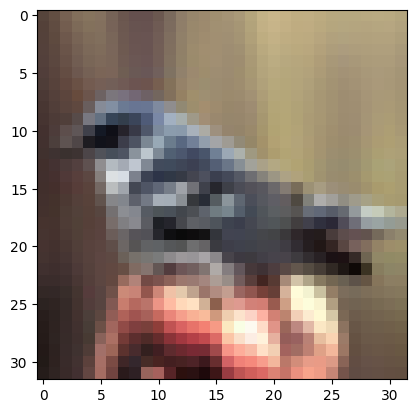

tensor([2])
bird
torch.Size([1, 3, 32, 32])


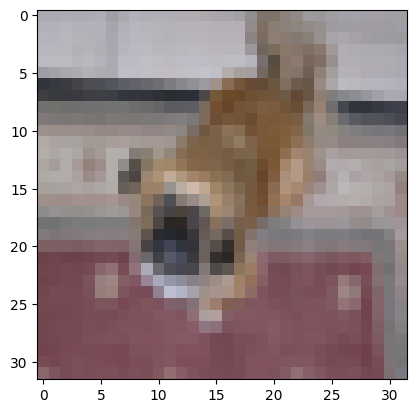

tensor([5])
dog
torch.Size([1, 3, 32, 32])


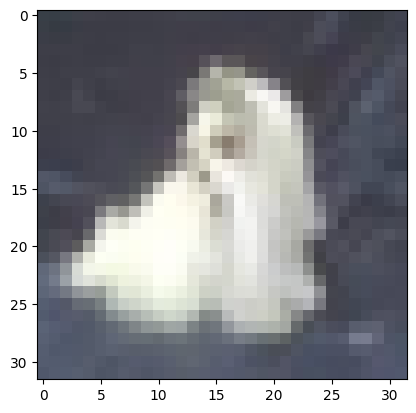

tensor([5])
dog
torch.Size([1, 3, 32, 32])


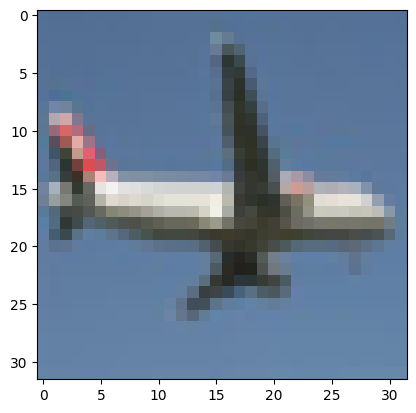

tensor([0])
plane
torch.Size([1, 3, 32, 32])


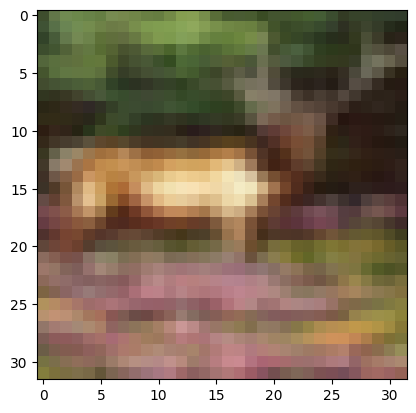

tensor([4])
deer
torch.Size([1, 3, 32, 32])


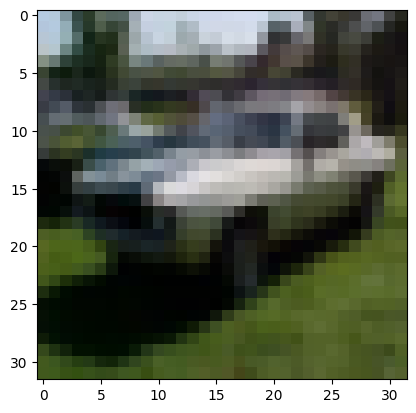

tensor([1])
car
torch.Size([1, 3, 32, 32])


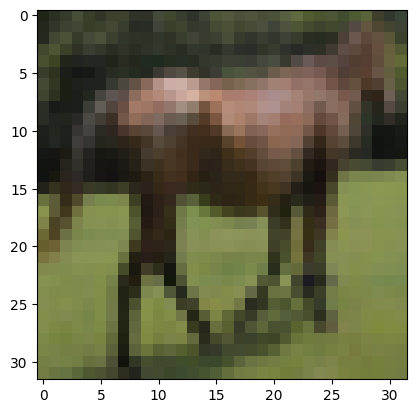

tensor([7])
horse
torch.Size([1, 3, 32, 32])


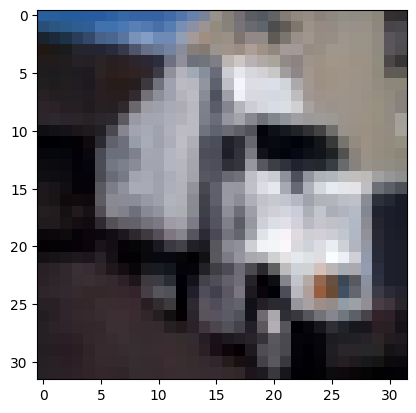

tensor([9])
truck
torch.Size([1, 3, 32, 32])


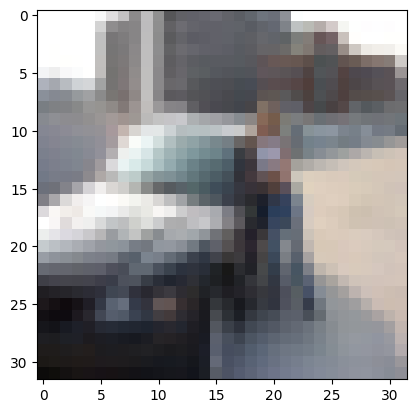

tensor([1])
car
torch.Size([1, 3, 32, 32])


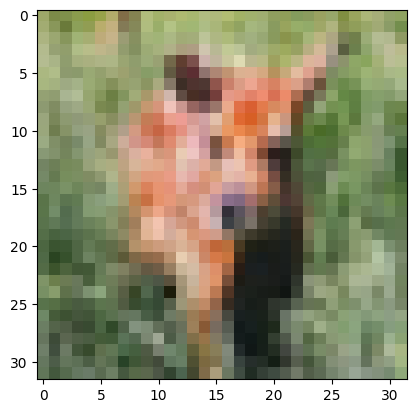

tensor([4])
deer
torch.Size([1, 3, 32, 32])


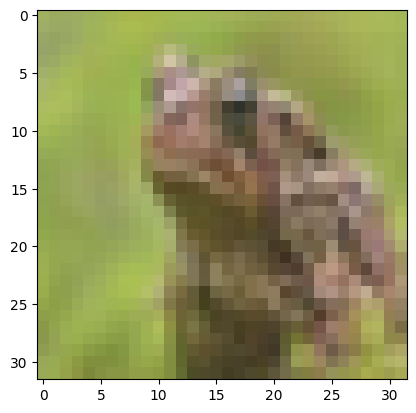

tensor([6])
frog


In [4]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

In [8]:
from torch.nn import ReLU, Softmax, Sequential, Linear, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d, Dropout, Dropout2d

def build_model_task4_fc_only(num_classes=10, p_fc=0.5):
    model = Sequential(
          Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
          MaxPool2d(2),
          Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
          MaxPool2d(2),
          Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
          MaxPool2d(2),

          AdaptiveAvgPool2d(1),
          Dropout(p=p_fc),
          Flatten(),
          Linear(128, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


def build_model_task4_both(num_classes=10, p_conv=0.2, p_fc=0.5):
    model = Sequential(
          Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
          Dropout2d(p=p_conv), MaxPool2d(2),
          Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
          Dropout2d(p=p_conv), MaxPool2d(2),
          Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
          Dropout2d(p=p_conv), MaxPool2d(2),

          AdaptiveAvgPool2d(1),
          Dropout(p=p_fc),
          Flatten(),
          Linear(128, num_classes)
      )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


def build_model_task4_conv_only(num_classes=10, p_conv=0.2):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        Dropout2d(p=p_conv),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        Dropout2d(p=p_conv),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        Dropout2d(p=p_conv),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, num_classes)
      )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


model, model_inference = build_model_task4_conv_only()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.0916, 0.0941, 0.1096, 0.1049, 0.1052, 0.0966, 0.1001, 0.0977, 0.0955,
         0.1047]], grad_fn=<SoftmaxBackward0>)
bird


In [9]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

Using device:  cuda:0
Trying dropout setting: fc_dropout(p=0.5)
Val loss at epoch 0: 1.5709705094622959
Val acc at epoch 0: 0.4356
Val loss at epoch 1: 1.404765116940638
Val acc at epoch 1: 0.4908
Val loss at epoch 2: 1.2902212108776068
Val acc at epoch 2: 0.5344
Val loss at epoch 3: 1.2206131622290155
Val acc at epoch 3: 0.5754
Val loss at epoch 4: 1.1897495058691425
Val acc at epoch 4: 0.5734
Val loss at epoch 5: 1.1466162405955564
Val acc at epoch 5: 0.5972
Val loss at epoch 6: 1.0910342495152905
Val acc at epoch 6: 0.6176
Val loss at epoch 7: 1.061996970586716
Val acc at epoch 7: 0.6226
Val loss at epoch 8: 1.0434584302507388
Val acc at epoch 8: 0.6358
Val loss at epoch 9: 1.039548324551552
Val acc at epoch 9: 0.6424
Val loss at epoch 10: 1.0144382365949594
Val acc at epoch 10: 0.6468
Val loss at epoch 11: 0.9415738806603061
Val acc at epoch 11: 0.6682
Val loss at epoch 12: 0.976731679242128
Val acc at epoch 12: 0.6558
Val loss at epoch 13: 0.9303450986837886
Val acc at epoch 13: 0

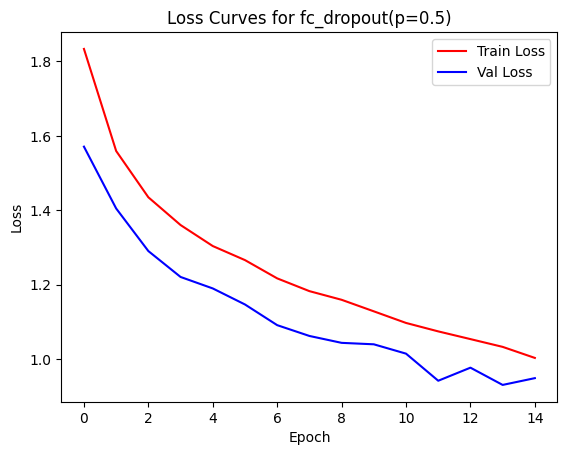

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.2)
Val loss at epoch 0: 1.662101079703896
Val acc at epoch 0: 0.4048
Val loss at epoch 1: 1.505224660703331
Val acc at epoch 1: 0.46
Val loss at epoch 2: 1.4121378948734065
Val acc at epoch 2: 0.4944
Val loss at epoch 3: 1.3589551205847674
Val acc at epoch 3: 0.514
Val loss at epoch 4: 1.2938825788011976
Val acc at epoch 4: 0.5454
Val loss at epoch 5: 1.278779872283814
Val acc at epoch 5: 0.5432
Val loss at epoch 6: 1.2363696033787575
Val acc at epoch 6: 0.5652
Val loss at epoch 7: 1.189319177417998
Val acc at epoch 7: 0.5902
Val loss at epoch 8: 1.183044780591491
Val acc at epoch 8: 0.5856
Val loss at epoch 9: 1.138870608654751
Val acc at epoch 9: 0.6148
Val loss at epoch 10: 1.1095784367269772
Val acc at epoch 10: 0.6162
Val loss at epoch 11: 1.107465986233608
Val acc at epoch 11: 0.6184
Val loss at epoch 12: 1.082397362988466
Val acc at epoch 12: 0.629
Val loss at epoch 13: 1.0537835207714397
Val acc at epoch 13: 0.6422
Va

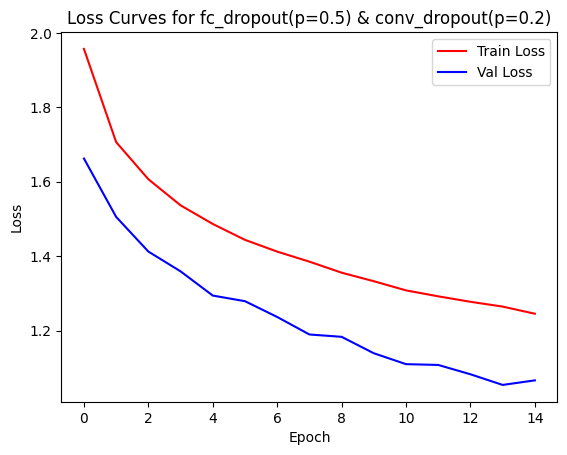

Trying dropout setting: conv_dropout(p=0.2)
Val loss at epoch 0: 1.6123512026610647
Val acc at epoch 0: 0.419
Val loss at epoch 1: 1.4440347821849167
Val acc at epoch 1: 0.4776
Val loss at epoch 2: 1.329805159644716
Val acc at epoch 2: 0.5252
Val loss at epoch 3: 1.2476773865663322
Val acc at epoch 3: 0.5596
Val loss at epoch 4: 1.1899056184064052
Val acc at epoch 4: 0.5812
Val loss at epoch 5: 1.1110407315242063
Val acc at epoch 5: 0.6098
Val loss at epoch 6: 1.0867066732637443
Val acc at epoch 6: 0.6288
Val loss at epoch 7: 1.04106421189703
Val acc at epoch 7: 0.631
Val loss at epoch 8: 0.9994925397216894
Val acc at epoch 8: 0.6528
Val loss at epoch 9: 0.9707569628004815
Val acc at epoch 9: 0.6706
Val loss at epoch 10: 0.9456894086424712
Val acc at epoch 10: 0.6722
Val loss at epoch 11: 0.939444325911771
Val acc at epoch 11: 0.6772
Val loss at epoch 12: 0.9025168589725616
Val acc at epoch 12: 0.6932
Val loss at epoch 13: 0.8756828141060604
Val acc at epoch 13: 0.6994
Val loss at epoc

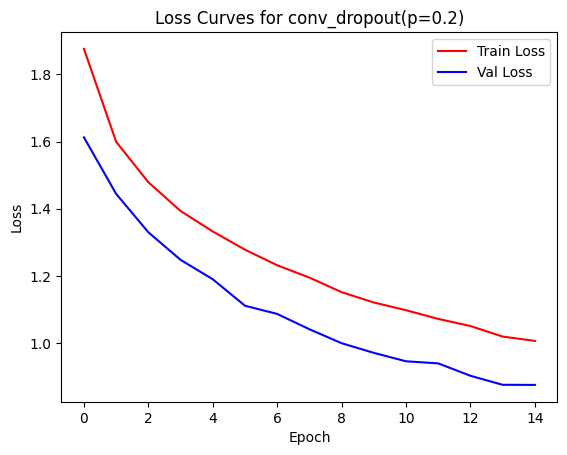

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.1)
Val loss at epoch 0: 1.6180115232042447
Val acc at epoch 0: 0.4174
Val loss at epoch 1: 1.495663847892907
Val acc at epoch 1: 0.449
Val loss at epoch 2: 1.3531791226119751
Val acc at epoch 2: 0.5246
Val loss at epoch 3: 1.3142026176877841
Val acc at epoch 3: 0.5354
Val loss at epoch 4: 1.2291107192920272
Val acc at epoch 4: 0.5746
Val loss at epoch 5: 1.1719905532849062
Val acc at epoch 5: 0.5896
Val loss at epoch 6: 1.1494598605070905
Val acc at epoch 6: 0.5944
Val loss at epoch 7: 1.1042967404529547
Val acc at epoch 7: 0.6076
Val loss at epoch 8: 1.0640231606307302
Val acc at epoch 8: 0.6346
Val loss at epoch 9: 1.0689396979702506
Val acc at epoch 9: 0.634
Val loss at epoch 10: 1.0129051337576216
Val acc at epoch 10: 0.6398
Val loss at epoch 11: 0.9980383595083929
Val acc at epoch 11: 0.6454
Val loss at epoch 12: 0.9607735507807155
Val acc at epoch 12: 0.6614
Val loss at epoch 13: 0.9492447083922708
Val acc at epoch 13: 

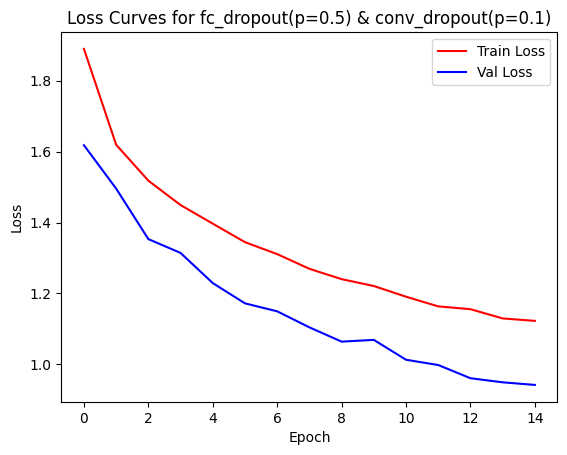

In [10]:
configs = [ {'name': 'fc_dropout(p=0.5)','build_model': lambda: build_model_task4_fc_only(10, 0.5)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.2)},
            {'name': 'conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_conv_only(10, p_conv=0.2)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.1)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.1)}
          ]

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying dropout setting: {config['name']}")

    model_builder = config['build_model']

    model, model_inference = model_builder()
    model.to(device)
    model_inference.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(15):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'dropout_results.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to optimizers_results.json


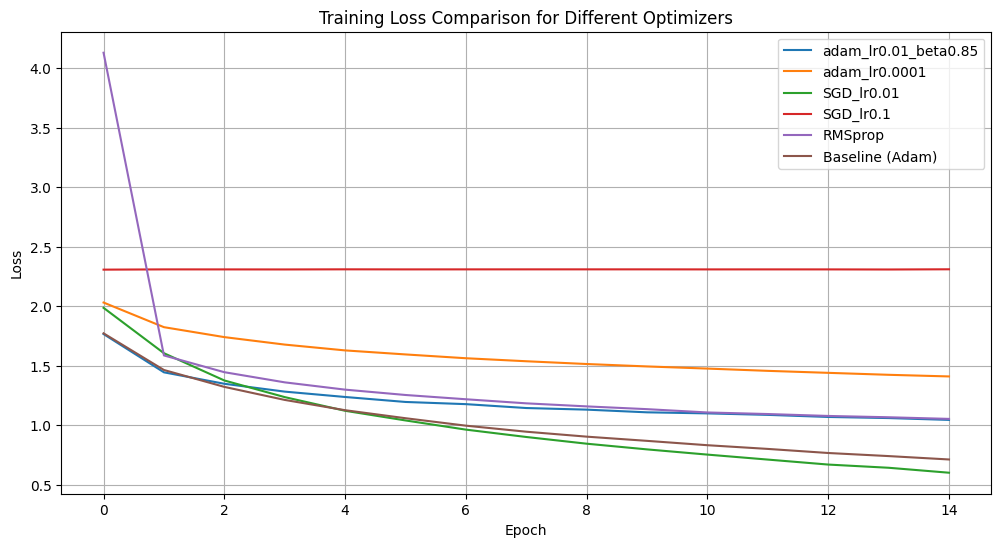

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline(no dropout)')

plt.title('Training Loss Comparison for Different Dropout settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

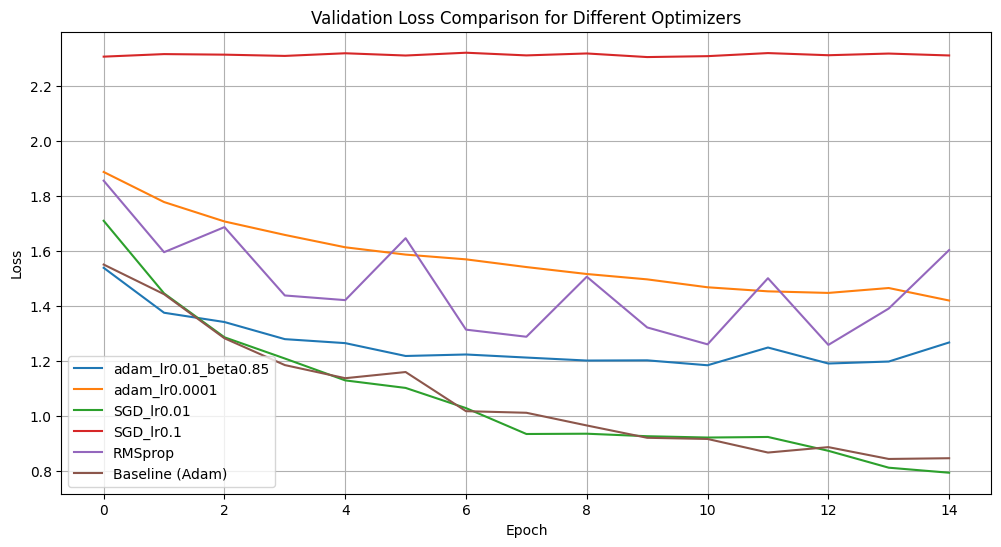

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

plt.plot(baseline_val_losses, label='Baseline (no dropoout)')

plt.title('Validation Loss Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

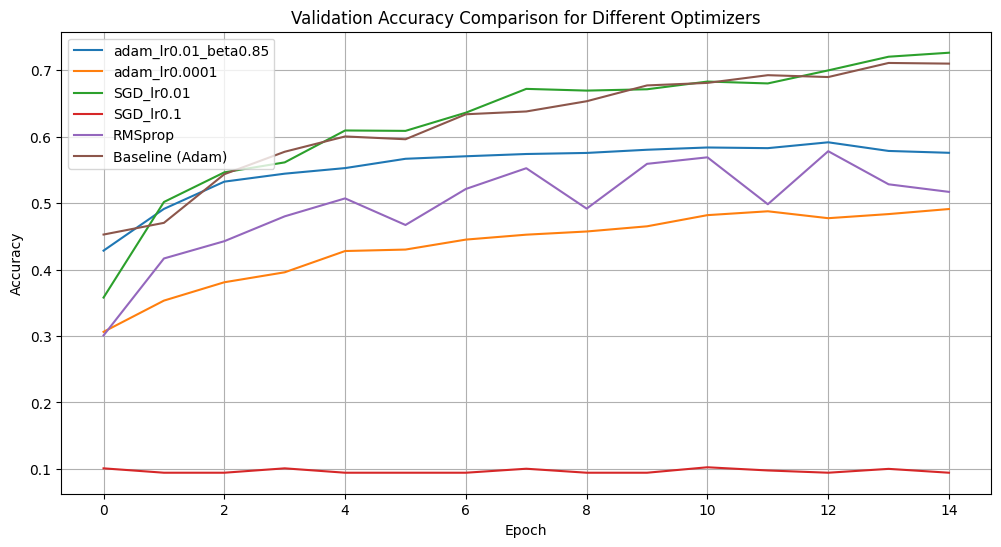

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

plt.plot(baseline_val_accs, label='Baseline (no dropout)')

plt.title('Validation Accuracy Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['Baseline (Adam)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (Adam),0.712818,0.845021,0.7098
adam_lr0.01_beta0.85,1.045242,1.266049,0.5756
adam_lr0.0001,1.410405,1.418583,0.4910
SGD_lr0.01,0.601520,0.792280,0.7262
SGD_lr0.1,2.310532,2.309857,0.0942
RMSprop,1.053760,1.602071,0.5168


### Augmentation

Using device:  cuda:0
Trying batch size: batch_size_64
Val loss at epoch 0: 1.6690846017644376
Val acc at epoch 0: 0.3996
Val loss at epoch 1: 1.4768553519550758
Val acc at epoch 1: 0.48
Val loss at epoch 2: 1.4250105966495563
Val acc at epoch 2: 0.4896
Val loss at epoch 3: 1.2525472105303896
Val acc at epoch 3: 0.554
Val loss at epoch 4: 1.1895082675957982
Val acc at epoch 4: 0.573
Val loss at epoch 5: 1.150333150278164
Val acc at epoch 5: 0.5956
Val loss at epoch 6: 1.1274471335773226
Val acc at epoch 6: 0.6088
Val loss at epoch 7: 1.0407365930231312
Val acc at epoch 7: 0.6344
Val loss at epoch 8: 1.062337400038031
Val acc at epoch 8: 0.6258
Val loss at epoch 9: 1.0435886775391012
Val acc at epoch 9: 0.6286
Val loss at epoch 10: 0.9799979434737677
Val acc at epoch 10: 0.656
Val loss at epoch 11: 1.036976335169394
Val acc at epoch 11: 0.6322
Val loss at epoch 12: 0.9417083399205268
Val acc at epoch 12: 0.674
Val loss at epoch 13: 0.9047459152680409
Val acc at epoch 13: 0.6848
Val loss

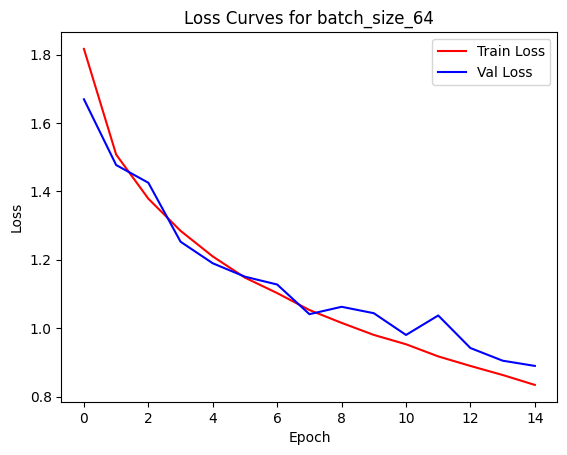

Trying batch size: batch_size_128
Val loss at epoch 0: 1.7192472606897353
Val acc at epoch 0: 0.3888
Val loss at epoch 1: 1.5273148179054261
Val acc at epoch 1: 0.4528
Val loss at epoch 2: 1.4607375115156174
Val acc at epoch 2: 0.484
Val loss at epoch 3: 1.3788849055767058
Val acc at epoch 3: 0.503
Val loss at epoch 4: 1.3242124885320663
Val acc at epoch 4: 0.527
Val loss at epoch 5: 1.281810748577118
Val acc at epoch 5: 0.5392
Val loss at epoch 6: 1.242475411295891
Val acc at epoch 6: 0.5596
Val loss at epoch 7: 1.180507081747055
Val acc at epoch 7: 0.5822
Val loss at epoch 8: 1.1475967735052108
Val acc at epoch 8: 0.588
Val loss at epoch 9: 1.1235215440392494
Val acc at epoch 9: 0.6018
Val loss at epoch 10: 1.1339596599340438
Val acc at epoch 10: 0.5964
Val loss at epoch 11: 1.0921419754624366
Val acc at epoch 11: 0.6074
Val loss at epoch 12: 1.0983207136392594
Val acc at epoch 12: 0.6126
Val loss at epoch 13: 1.0650132656097413
Val acc at epoch 13: 0.6172
Val loss at epoch 14: 0.996

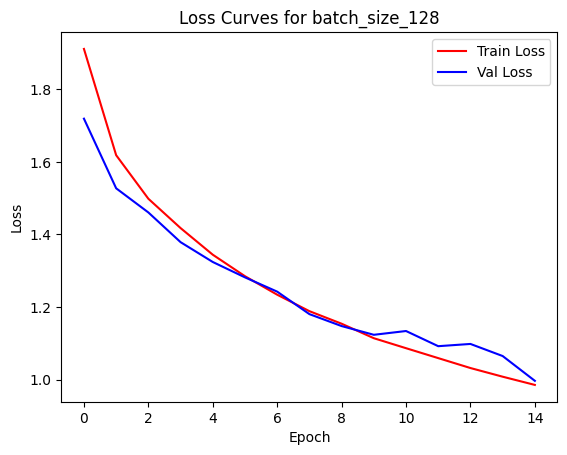

Trying batch size: batch_size_16
Val loss at epoch 0: 1.4436390946467463
Val acc at epoch 0: 0.4736
Val loss at epoch 1: 1.236954752248697
Val acc at epoch 1: 0.5686
Val loss at epoch 2: 1.0913041475862741
Val acc at epoch 2: 0.6144
Val loss at epoch 3: 1.0282200009297258
Val acc at epoch 3: 0.638
Val loss at epoch 4: 0.9534275678400034
Val acc at epoch 4: 0.665
Val loss at epoch 5: 0.998384840381793
Val acc at epoch 5: 0.6448
Val loss at epoch 6: 0.8599948580272663
Val acc at epoch 6: 0.6988
Val loss at epoch 7: 0.8464142435941452
Val acc at epoch 7: 0.7
Val loss at epoch 8: 0.8365536503041514
Val acc at epoch 8: 0.7054
Val loss at epoch 9: 0.8759840320283994
Val acc at epoch 9: 0.6966
Val loss at epoch 10: 0.825962741820576
Val acc at epoch 10: 0.7188
Val loss at epoch 11: 0.8247169405698015
Val acc at epoch 11: 0.7216
Val loss at epoch 12: 0.798662123612512
Val acc at epoch 12: 0.7258
Val loss at epoch 13: 0.8059916164452275
Val acc at epoch 13: 0.7208
Val loss at epoch 14: 0.830405

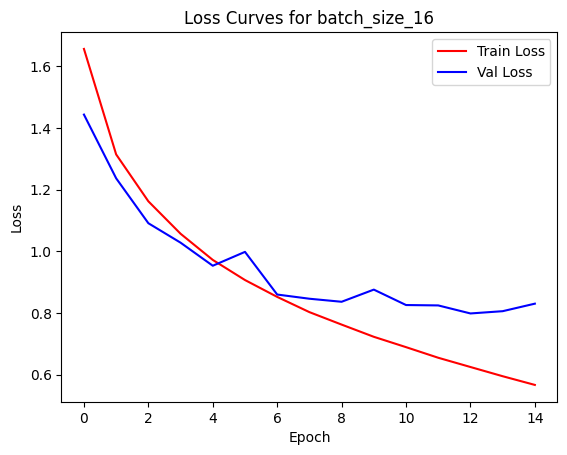

In [ ]:
# TODO: Experiments with batch size
from torch.optim import Adam

configs = [ {'name': 'batch_size_64','size': 64},
            {'name': 'batch_size_128','size': 128},
            {'name': 'batch_size_16', 'size': 16}
          ]

### TODO: dokoncit config setup

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying batch size: {config['name']}")

    # Re-initialize model and optimizer for each batch size experiment
    model, model_inference = build_model_task3()
    model.to(device)
    model_inference.to(device)
    optimizer = Adam(model.parameters())


    batch_size = config['size']
    dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(15):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
import json

# Combine the losses and accuracies into a single dictionary
results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

# Specify the filename
output_filename = 'optimizers_batchsize_results.json'

# Dump the dictionary to a JSON file
with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to optimizers_batchsize_results.json


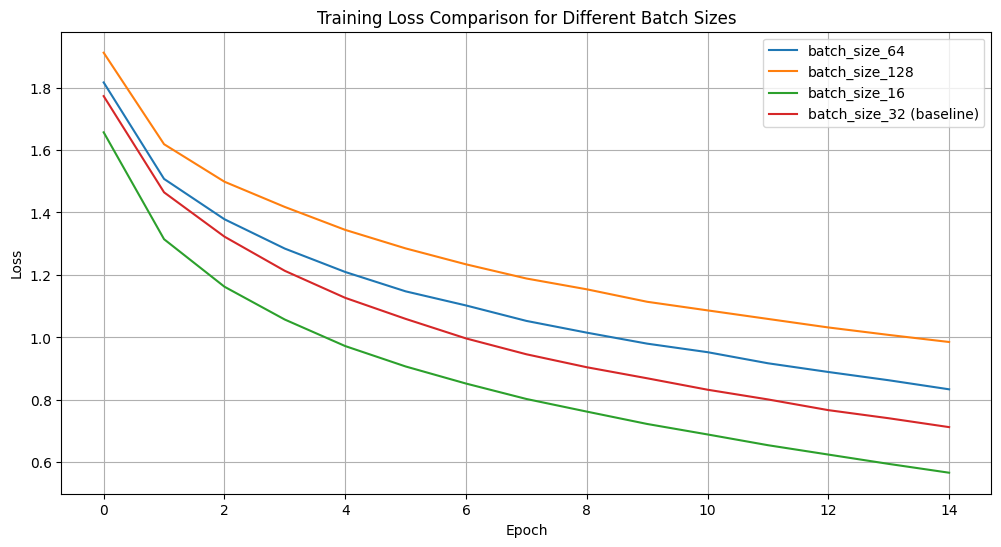

In [ ]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(losses[config['name']][0][0], label=config['name'])

plt.plot(baseline_train_losses, label='batch_size_32 (baseline)')

plt.title('Training Loss Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

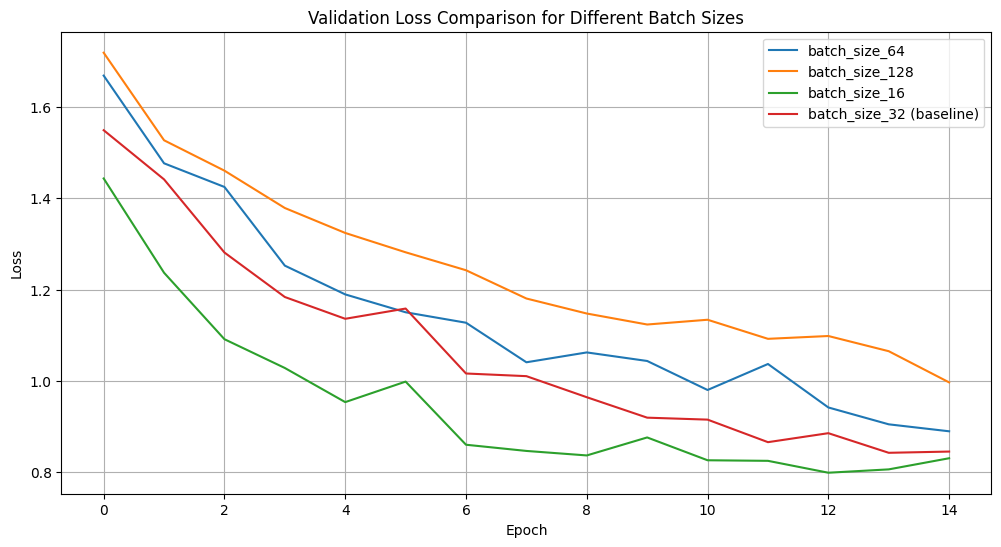

In [ ]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(losses[config['name']][1][0], label=config['name'])

# Assuming you have the baseline model's val_losses stored in baseline_val_losses
plt.plot(baseline_val_losses, label='batch_size_32 (baseline)')

plt.title('Validation Loss Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

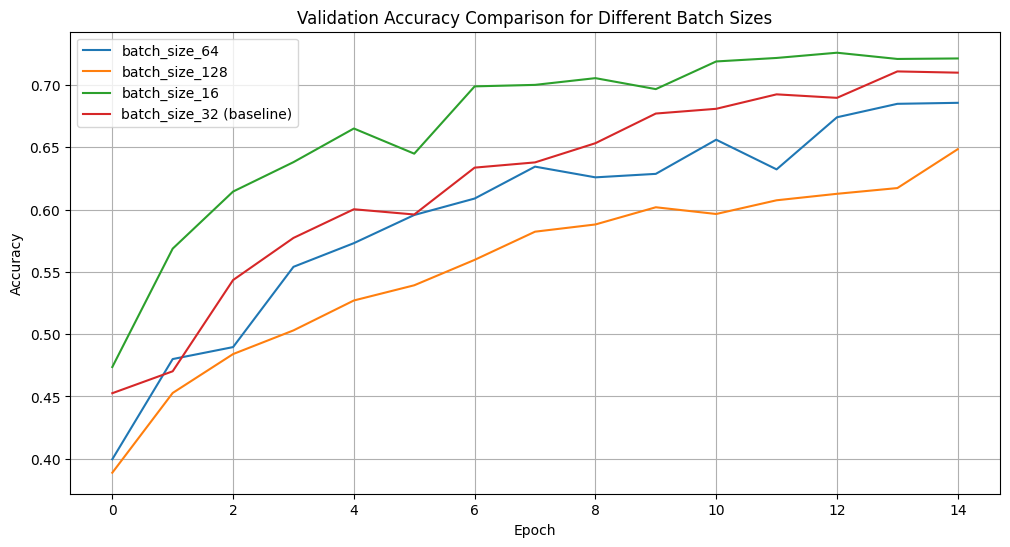

In [ ]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(accuracies[config['name']][0], label=config['name'])

# Assuming you have the baseline model's val_accs stored in baseline_val_accs
plt.plot(baseline_val_accs, label='batch_size_32 (baseline)')

plt.title('Validation Accuracy Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['batch_size_32 (baseline)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
batch_size_32 (baseline),0.712818,0.845021,0.7098
batch_size_64,0.833895,0.889472,0.6856
batch_size_128,0.985370,0.996659,0.6484
batch_size_16,0.566856,0.830405,0.7212
